# LSGAN Replication — ICS 555
**Paper:** Least Squares Generative Adversarial Networks (Mao et al., 2017)  
**Dataset:** LSUN Church Outdoor (64×64)  

## Connectivity

In [1]:
%%javascript
function ClickConnect(){
console.log("Working");
document.querySelector("colab-toolbar-button#connect").click()
}setInterval(ClickConnect,60000)

<IPython.core.display.Javascript object>

## Mount Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/zamsi-ajegetina/lsgans.git /content/lsgan

Mounted at /content/drive
Cloning into '/content/lsgan'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 34 (delta 4), reused 34 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 1.38 MiB | 6.19 MiB/s, done.
Resolving deltas: 100% (4/4), done.


## Install Dependencies

In [3]:
%cd /content/lsgan
!pip install -q PyYAML tqdm pytorch-fid scipy
# torch and torchvision are already installed on Colab

/content/lsgan


## Verify GPU

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Switch runtime to GPU.")

CUDA available: True
GPU: Tesla T4


## Configure Paths
Update `DATA_NPY` if you placed the file elsewhere on Drive.

In [4]:
import yaml, glob, os

DATA_NPY   = "/content/drive/MyDrive/Colab Notebooks/data/lsunchurch.npy"
OUTPUT_DIR = "/content/drive/MyDrive/lsgan_output"

# Verify the data file exists before patching configs
assert os.path.exists(DATA_NPY), f"Data file not found: {DATA_NPY}"
print("Data file found.")

os.makedirs(OUTPUT_DIR, exist_ok=True)

for cfg_path in sorted(glob.glob("configs/*lsun_church*.yaml")):
    with open(cfg_path) as f:
        cfg = yaml.safe_load(f)
    cfg["data_root"]   = DATA_NPY
    cfg["output_dir"]  = OUTPUT_DIR
    cfg["num_workers"] = 2
    with open(cfg_path, "w") as f:
        yaml.dump(cfg, f, default_flow_style=False)
    print(f"Updated: {cfg_path}")

Data file found.
Updated: configs/dcgan_lsun_church.yaml
Updated: configs/dcgan_lsun_church_nobn.yaml
Updated: configs/lsgan_lsun_church.yaml
Updated: configs/lsgan_lsun_church_nobn.yaml


## Gaussian Mixture Stability Experiment
Replicates Figure 8 from the paper. Lightweight — runs in a few minutes on CPU.

Using device: cuda
Training LSGAN on Gaussian mixture...
  [lsgan] step 5000/40000 snapshot saved
  [lsgan] step 15000/40000 snapshot saved
  [lsgan] step 25000/40000 snapshot saved
  [lsgan] step 40000/40000 snapshot saved
Training vanilla GAN on Gaussian mixture...
  [vanilla] step 5000/40000 snapshot saved
  [vanilla] step 15000/40000 snapshot saved
  [vanilla] step 25000/40000 snapshot saved
  [vanilla] step 40000/40000 snapshot saved
Saved: /content/drive/MyDrive/lsgan_output/plots/gaussian_mixture_stability.png


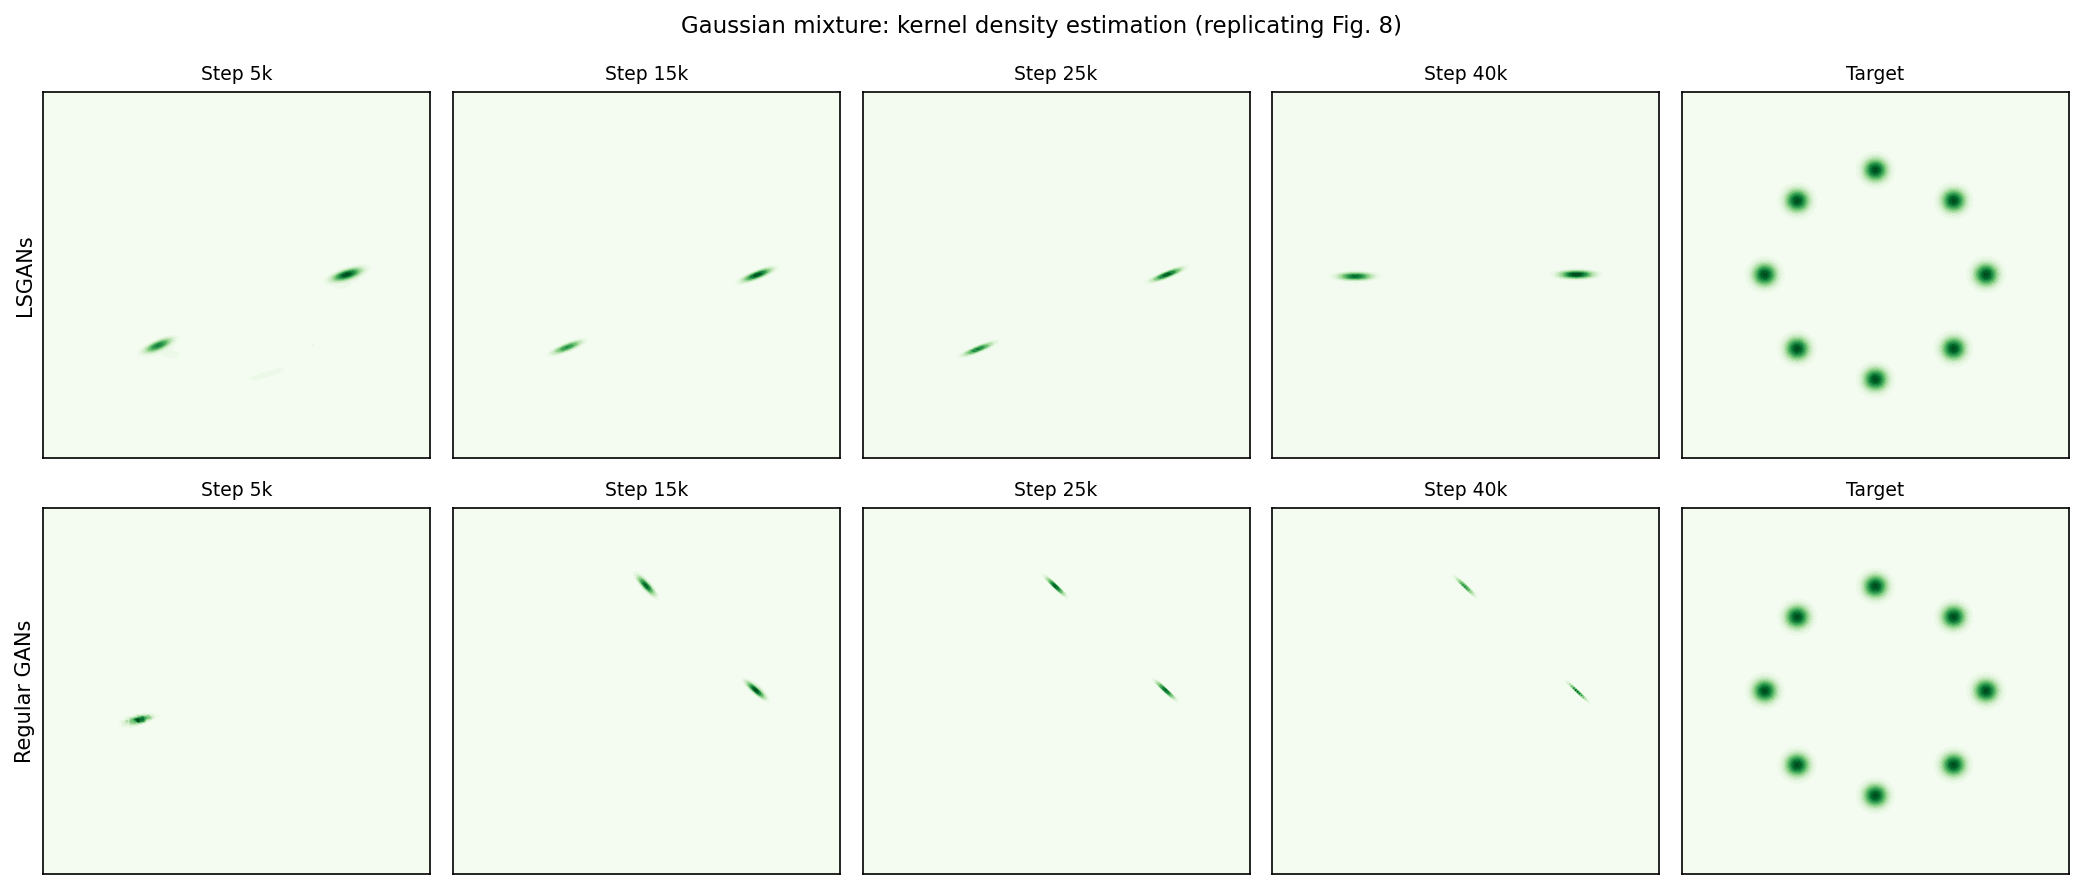

In [ ]:
!python src/gaussian_exp.py \
    --output_dir /content/drive/MyDrive/lsgan_output/plots \
    --seed 42

# Display the result
from IPython.display import Image
Image("/content/drive/MyDrive/lsgan_output/plots/gaussian_mixture_stability.png")

## Train LSGAN on LSUN Church
Main experiment: LSGAN with batch normalization.

In [ ]:
!python src/train.py --config configs/lsgan_lsun_church.yaml

Using device: cuda
Dataset: 126227 samples, 1972 batches/epoch
Epoch 001 | D: 0.1860 | G: 0.5685 | 419s
Epoch 002 | D: 0.1914 | G: 0.4072 | 845s
Epoch 003 | D: 0.1671 | G: 0.4117 | 1270s
Epoch 004 | D: 0.1492 | G: 0.4240 | 1695s
Epoch 005 | D: 0.1351 | G: 0.4195 | 2121s
Epoch 006 | D: 0.1224 | G: 0.4170 | 2548s
Epoch 007 | D: 0.1519 | G: 0.3757 | 2974s
Epoch 008 | D: 0.1091 | G: 0.4190 | 3400s
Epoch 009 | D: 0.1463 | G: 0.3661 | 3825s
Epoch 010 | D: 0.1097 | G: 0.4142 | 4250s
Epoch 011 | D: 0.1456 | G: 0.3628 | 4677s
Epoch 012 | D: 0.0958 | G: 0.4143 | 5101s
Epoch 013 | D: 0.1150 | G: 0.3949 | 5526s
Epoch 014 | D: 0.0913 | G: 0.4193 | 5950s
Epoch 015 | D: 0.1386 | G: 0.3648 | 6375s
Epoch 016 | D: 0.1108 | G: 0.3939 | 6800s
Epoch 017 | D: 0.0848 | G: 0.4169 | 7223s
Epoch 018 | D: 0.0834 | G: 0.4215 | 7645s
Epoch 019 | D: 0.0794 | G: 0.4230 | 8068s
Epoch 020 | D: 0.0769 | G: 0.4269 | 8491s
Epoch 021 | D: 0.0737 | G: 0.4286 | 8915s
Epoch 022 | D: 0.0715 | G: 0.4309 | 9337s
Epoch 023 | D: 

## Train Vanilla DCGAN on LSUN Church
Baseline: standard GAN with BCE loss (same architecture as LSGAN).

In [ ]:
!python src/train.py --config configs/dcgan_lsun_church.yaml

Using device: cuda
Epoch 001 | D: 0.6909 | G: 3.5823 | 410s
Epoch 002 | D: 0.7328 | G: 2.9598 | 827s
Epoch 003 | D: 0.6411 | G: 3.0178 | 1245s
Epoch 004 | D: 0.5369 | G: 3.2200 | 1662s
Epoch 005 | D: 0.4947 | G: 3.3305 | 2079s
Epoch 006 | D: 0.4588 | G: 3.3891 | 2498s
Epoch 007 | D: 0.4294 | G: 3.5251 | 2915s
Epoch 008 | D: 0.4076 | G: 3.6314 | 3332s
Epoch 009 | D: 0.4190 | G: 3.6736 | 3749s
Epoch 010 | D: 0.3840 | G: 3.6954 | 4165s
Epoch 011 | D: 0.3880 | G: 3.7401 | 4582s
Epoch 012 | D: 0.3456 | G: 3.7841 | 4999s
Epoch 013 | D: 0.3735 | G: 3.8375 | 5415s
Epoch 014 | D: 0.3291 | G: 3.9038 | 5832s
Epoch 015 | D: 0.3463 | G: 3.9257 | 6248s
Epoch 016 | D: 0.3406 | G: 3.9297 | 6666s
Epoch 017 | D: 0.3229 | G: 4.0253 | 7082s
Epoch 018 | D: 0.3178 | G: 4.1470 | 7498s
Epoch 019 | D: 0.2941 | G: 4.0904 | 7914s
Epoch 020 | D: 0.3091 | G: 4.2638 | 8329s
Epoch 021 | D: 0.2793 | G: 4.1912 | 8748s
Epoch 022 | D: 0.2821 | G: 4.2758 | 9164s
Epoch 023 | D: 0.2908 | G: 4.3584 | 9580s
Epoch 024 | D: 0.

## Stability Ablation: LSGAN without BatchNorm
Replicates Section 4.3 BN_GD experiment with Adam optimizer.

In [ ]:
!python src/train.py --config configs/lsgan_lsun_church_nobn.yaml

Using device: cuda
Epoch 001 | D: 0.1296 | G: 0.5020 | 414s
Epoch 002 | D: 0.1749 | G: 0.3639 | 828s
Epoch 003 | D: 0.1743 | G: 0.3597 | 1243s
Epoch 004 | D: 0.1756 | G: 0.3698 | 1657s
Epoch 005 | D: 0.1784 | G: 0.3473 | 2071s
Epoch 006 | D: 0.1829 | G: 0.3592 | 2490s
Epoch 007 | D: 0.1775 | G: 0.3404 | 2904s
Epoch 008 | D: 0.1783 | G: 0.3290 | 3317s
Epoch 009 | D: 0.1724 | G: 0.3313 | 3731s
Epoch 010 | D: 0.1728 | G: 0.3257 | 4145s
Epoch 011 | D: 0.1730 | G: 0.3263 | 4560s
Epoch 012 | D: 0.1813 | G: 0.3143 | 4974s
Epoch 013 | D: 0.1726 | G: 0.3115 | 5388s
Epoch 014 | D: 0.1757 | G: 0.3072 | 5801s
Epoch 015 | D: 0.1644 | G: 0.3144 | 6215s
Training complete.


## Stability Ablation: Vanilla GAN without BatchNorm

In [ ]:
!python src/train.py --config configs/dcgan_lsun_church_nobn.yaml

Using device: cuda
Epoch 001 | D: 1.0626 | G: 1.9591 | 404s
Epoch 002 | D: 1.1111 | G: 1.5441 | 817s
Epoch 003 | D: 1.3124 | G: 0.9711 | 1231s
Epoch 004 | D: 1.1963 | G: 1.3161 | 1645s
Epoch 005 | D: 1.2259 | G: 1.2015 | 2059s
Epoch 006 | D: 1.2094 | G: 1.3356 | 2474s
Epoch 007 | D: 1.1942 | G: 1.3525 | 2887s
Epoch 008 | D: 1.2166 | G: 1.2845 | 3299s
Epoch 009 | D: 1.1794 | G: 1.3503 | 3711s
Epoch 010 | D: 1.2011 | G: 1.2703 | 4124s
Epoch 011 | D: 1.2145 | G: 1.2576 | 4539s
Epoch 012 | D: 1.1867 | G: 1.2785 | 4951s
Epoch 013 | D: 1.1753 | G: 1.3127 | 5365s
Epoch 014 | D: 1.1653 | G: 1.2962 | 5778s
Epoch 015 | D: 1.1564 | G: 1.3492 | 6190s
Training complete.


## Plot Training Curves
Overlays D/G loss curves for all experiments.

Saved: /content/drive/MyDrive/lsgan_output/plots/training_curves.png


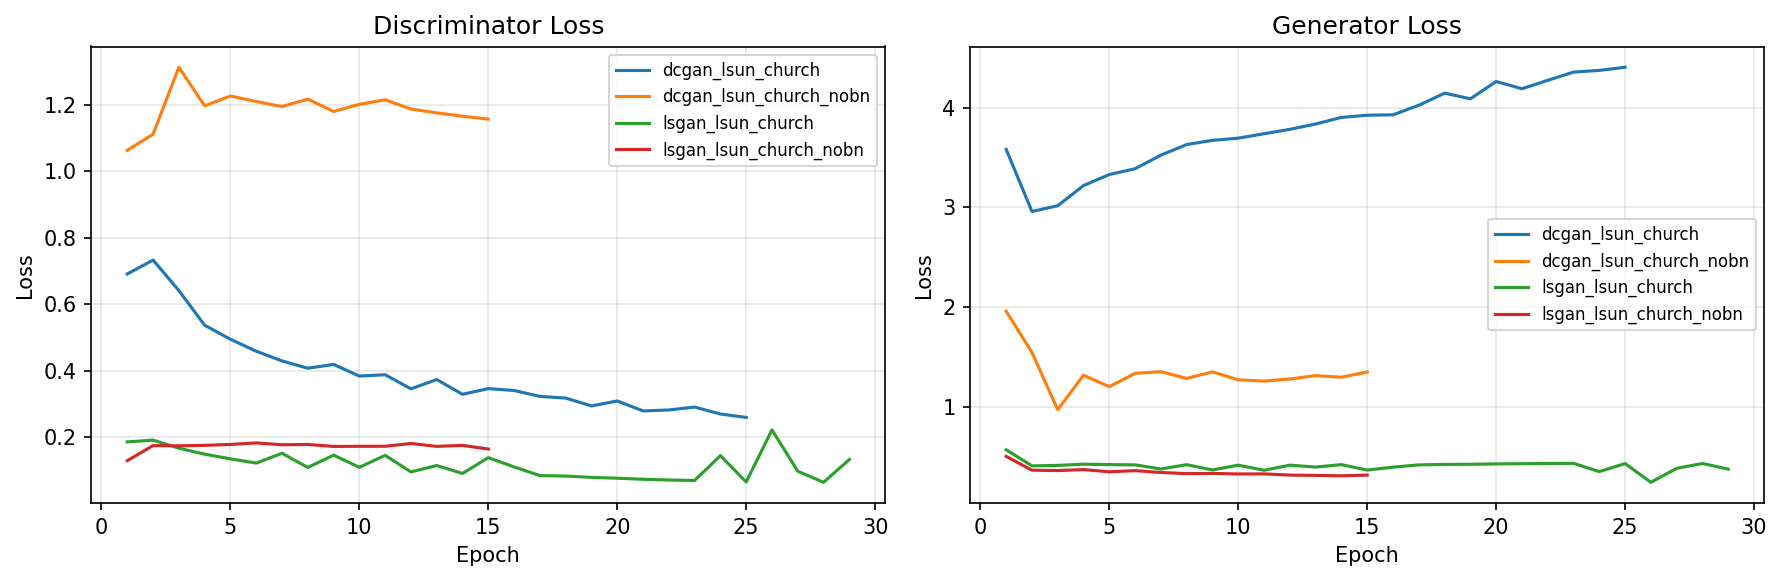

In [ ]:
!python src/evaluate.py \
    --plot_curves \
    --log_dir /content/drive/MyDrive/lsgan_output/logs \
    --output_dir /content/drive/MyDrive/lsgan_output/plots

from IPython.display import Image
Image("/content/drive/MyDrive/lsgan_output/plots/training_curves.png")

## Generate Image Grids + FID Samples
Run once per experiment after training completes.

In [9]:
CKPT_DIR = "/content/drive/MyDrive/lsgan_output/checkpoints"
PLOT_DIR = "/content/drive/MyDrive/lsgan_output/plots"

experiments = [
    ("configs/lsgan_lsun_church.yaml",       f"{CKPT_DIR}/lsgan_lsun_church/ckpt_epoch025.pt"),
    ("configs/dcgan_lsun_church.yaml",        f"{CKPT_DIR}/dcgan_lsun_church/ckpt_epoch025.pt"),
    ("configs/lsgan_lsun_church_nobn.yaml",   f"{CKPT_DIR}/lsgan_lsun_church_nobn/ckpt_epoch015.pt"),
    ("configs/dcgan_lsun_church_nobn.yaml",   f"{CKPT_DIR}/dcgan_lsun_church_nobn/ckpt_epoch015.pt"),
]

for cfg, ckpt in experiments:
    print(f"\n--- Evaluating: {cfg} ---")
    !python src/evaluate.py \
        --config {cfg} \
        --ckpt {ckpt} \
        --output_dir {PLOT_DIR} \
        --fid_samples 5000


--- Evaluating: configs/lsgan_lsun_church.yaml ---
Saved image grid: /content/drive/MyDrive/lsgan_output/plots/lsgan_lsun_church_grid.png
Saved 5000 images to /content/drive/MyDrive/lsgan_output/plots/lsgan_lsun_church_fid_samples

To compute FID, run:
  python -m pytorch_fid /content/drive/MyDrive/lsgan_output/plots/lsgan_lsun_church_fid_samples <path_to_real_image_stats_or_folder>

--- Evaluating: configs/dcgan_lsun_church.yaml ---
Saved image grid: /content/drive/MyDrive/lsgan_output/plots/dcgan_lsun_church_grid.png
Saved 5000 images to /content/drive/MyDrive/lsgan_output/plots/dcgan_lsun_church_fid_samples

To compute FID, run:
  python -m pytorch_fid /content/drive/MyDrive/lsgan_output/plots/dcgan_lsun_church_fid_samples <path_to_real_image_stats_or_folder>

--- Evaluating: configs/lsgan_lsun_church_nobn.yaml ---
Saved image grid: /content/drive/MyDrive/lsgan_output/plots/lsgan_lsun_church_nobn_grid.png
Saved 5000 images to /content/drive/MyDrive/lsgan_output/plots/lsgan_lsun_chu

## Compute FID Scores
Compares generated samples against real LSUN Church images.

In [7]:
import sys, os
sys.path.insert(0, 'src')

# Save real images from npy to a temp folder for FID reference
import numpy as np
import torchvision.utils as vutils
import torch

REAL_DIR = "/content/real_church_fid"
os.makedirs(REAL_DIR, exist_ok=True)

data = np.load("/content/drive/MyDrive/Colab Notebooks/data/lsunchurch.npy")
N_REAL = 5000
for i in range(N_REAL):
    img = torch.from_numpy(data[i]).permute(2, 0, 1).float() / 255.0
    vutils.save_image(img, f"{REAL_DIR}/{i:05d}.png")
    if (i+1) % 500 == 0:
        print(f"{i+1}/{N_REAL}")

print("Real images saved.")

500/5000
1000/5000
1500/5000
2000/5000
2500/5000
3000/5000
3500/5000
4000/5000
4500/5000
5000/5000
Real images saved.


In [10]:
PLOT_DIR = "/content/drive/MyDrive/lsgan_output/plots"

for exp in ["lsgan_lsun_church", "dcgan_lsun_church",
            "lsgan_lsun_church_nobn", "dcgan_lsun_church_nobn"]:
    fid_samples = f"{PLOT_DIR}/{exp}_fid_samples"
    print(f"\nFID for {exp}:")
    !python -m pytorch_fid {fid_samples} /content/real_church_fid --device cuda


FID for lsgan_lsun_church:
100% 100/100 [01:17<00:00,  1.29it/s]
100% 100/100 [00:18<00:00,  5.31it/s]
FID:  32.168490835886104

FID for dcgan_lsun_church:
100% 100/100 [01:15<00:00,  1.33it/s]
100% 100/100 [00:18<00:00,  5.27it/s]
FID:  27.344537381387028

FID for lsgan_lsun_church_nobn:
100% 100/100 [01:06<00:00,  1.50it/s]
100% 100/100 [00:19<00:00,  5.23it/s]
FID:  79.41581108439831

FID for dcgan_lsun_church_nobn:
100% 100/100 [01:02<00:00,  1.59it/s]
100% 100/100 [00:19<00:00,  5.21it/s]
FID:  101.03394224008105


## Display Generated Image Grids

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

PLOT_DIR = "/content/drive/MyDrive/lsgan_output/plots"
exps = ["lsgan_lsun_church", "dcgan_lsun_church",
        "lsgan_lsun_church_nobn", "dcgan_lsun_church_nobn"]

fig, axes = plt.subplots(1, len(exps), figsize=(20, 5))
for ax, exp in zip(axes, exps):
    grid_path = f"{PLOT_DIR}/{exp}_grid.png"
    if os.path.exists(grid_path):
        ax.imshow(mpimg.imread(grid_path))
        ax.set_title(exp.replace('_lsun_church', '').replace('_', ' '), fontsize=9)
    else:
        ax.set_title(f"{exp}\n(not found)")
    ax.axis('off')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/all_grids_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.